# PhysioNet 2009 MI Fine-Tuning with SignalJEPA Downstream Variants

Downstream fine-tuning on **PhysioNet EEG Motor Movement/Imagery Dataset (PhysionetMI)** using the updated Lee2019 workflow as the template.

- Dataset: PhysionetMI (MOABB) with imagined motor imagery runs
- Task: **left_hand vs right_hand** subset only
- EEG channels only; average reference before preprocessing; bandpass 0.5-40 Hz; resample to 128 Hz
- 5-fold stratified within-subject cross-validation
- Model: configurable via `CONFIG["model_name"]`
- Pretrained weights: Hugging Face S-JEPA checkpoint through `from_pretrained`
- Fine-tuning strategy: configurable via `CONFIG["strategy"]` (`new` or `full`)
- Training: Braindecode EEGClassifier with the same updated workflow pattern as the current Lee2019 notebook
- Optional fallback: load an already saved Braindecode concat dataset through `CONFIG["preprocessed_concat_dir"]` if you do not want to build from MOABB here


# 1. Setup

## 1.1. Import Libraries

In [1]:
import os
import random
import sys
from pathlib import Path
import platform
import json
import hashlib
from datetime import datetime
import math

import numpy as np
from numpy import multiply

import torch
from torch.utils.data import Subset

from braindecode import EEGClassifier
from braindecode.models import SignalJEPA_PreLocal, SignalJEPA_PostLocal, SignalJEPA_Contextual
from braindecode.datasets import MOABBDataset, BaseConcatDataset
from braindecode.datautil import load_concat_dataset
from braindecode.preprocessing import (
    Preprocessor,
    preprocess,
    create_windows_from_events,
)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, roc_auc_score
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit

import builtins

import mne
mne.set_log_level("WARNING")

print("All imports loaded successfully.")

/Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports loaded successfully.


## 1.2. Runtime & Path Validation

In [2]:
print("Runtime Environment:")
print(f"  - Python: {sys.version}")
print(f"  - Platform: {platform.platform()}")

WORKING_DIR = Path.cwd().parent
print(f"\nWorking directory: {WORKING_DIR}")

Runtime Environment:
  - Python: 3.11.15 (main, Apr  9 2026, 01:18:52) [Clang 21.0.0 (clang-2100.0.123.102)]
  - Platform: macOS-26.2-arm64-arm-64bit

Working directory: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA


# 2. Configuration

## 2.1. Config

In [3]:
CONFIG = {
    # Paths
    "artifact_dir": str(WORKING_DIR / "artifacts" / "physionet-2009-fine-tuning"),

    # Dataset source
    # - "moabb": build PhysionetMI through braindecode.datasets.MOABBDataset
    # - "concat": load an already saved Braindecode concat dataset from preprocessed_concat_dir
    "dataset_source": "moabb",
    "dataset_name": "PhysionetMI",
    "preprocessed_concat_dir": None,

    # PhysioNetMI selection
    "labels_to_keep": ["left_hand", "right_hand"],
    "exclude_subjects": [],
    "subjects_to_use": [109],  # None = auto-select last 7 valid subjects
    "moabb_dataset_kwargs": {
        "imagined": True,
        "executed": False,
    },

    # Reproducibility
    "seed": 12,
    "set_seed": True,

    # Preprocessing
    "sfreq": 128,
    "bandpass_low": 0.5,
    "bandpass_high": 40.0,

    # Paradigm settings
    "paradigm": "MI",  # MI only

    # Model settings
    "model_name": "SignalJEPA_PreLocal",  # SignalJEPA_PreLocal, SignalJEPA_PostLocal, SignalJEPA_Contextual

    # Strategy settings
    "strategy": "full",  # new, full
    "warmup_epochs": 10,

    # Cross-validation
    "cv_folds": 5,
    "val_split": 0.2,

    # Training
    "batch_size": 32,
    "n_epochs": 5000,
    "early_stopping_patience": 50,
    "learning_rate": 0.001,
}

# Output verbosity flags (set to True for more detailed output)
LOG_COMPACT = True
PRINT_MODEL_SUMMARY = False
PRINT_FREEZE_DETAILS = False
PRINT_FOLD_CLASS_COUNTS = False


In [4]:
PARADIGM_CONFIGS = {
    "MI": {
        "n_classes": 2,
        "base_trial_duration_s": 3.0,
        "target_window_duration_s": 3.2,
    },
}

PHYSIONET_ALL_SUBJECTS = list(range(1, 110))
PHYSIONET_VALID_SUBJECTS = [s for s in PHYSIONET_ALL_SUBJECTS if s not in set(CONFIG["exclude_subjects"])]
DEFAULT_SUBJECTS = PHYSIONET_VALID_SUBJECTS[-7:]

CLASSES_MAPPING = {label: idx for idx, label in enumerate(CONFIG["labels_to_keep"])}


## 2.2. Create Artifact Directory

In [5]:
def create_run_id():
    # Generate unique run ID from timestamp + config hash.
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    config_str = json.dumps(CONFIG, sort_keys=True, default=str)
    config_hash = hashlib.md5(config_str.encode()).hexdigest()[:8]
    return f"{timestamp}_{config_hash}"

In [6]:
RUN_ID = create_run_id()
ARTIFACT_DIR = Path(CONFIG["artifact_dir"]) / CONFIG["paradigm"] / RUN_ID
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

## 2.3. Initialize Logger

In [7]:
LOG_PATH = ARTIFACT_DIR / "run.log"
_LOG_FILE_HANDLE = open(LOG_PATH, "a", buffering=1)

def _timestamped_print(*args, **kwargs):
    sep = kwargs.pop("sep", " ")
    end = kwargs.pop("end", "\n")
    flush = kwargs.pop("flush", False)
    file = kwargs.pop("file", None)

    message = sep.join(str(arg) for arg in args)

    # Preserve visual spacing for prints like print("\n...")
    leading_newlines = len(message) - len(message.lstrip("\n"))
    message_body = message[leading_newlines:]

    def _write_target(text):
        if file is None:
            sys.__stdout__.write(text) # type: ignore
            if flush:
                sys.__stdout__.flush() # type: ignore
        else:
            file.write(text)
            if flush and hasattr(file, "flush"):
                file.flush()

    # Apply leading blank lines first without timestamps
    if leading_newlines > 0:
        blanks = "\n" * leading_newlines
        _write_target(blanks)
        _LOG_FILE_HANDLE.write(blanks)

    if message_body:
        ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        stamped = f"[{ts}] {message_body}"
        _write_target(stamped + end)
        _LOG_FILE_HANDLE.write(stamped + end)
    else:
        # If only newlines were printed, preserve end behavior without adding a timestamp
        _write_target(end)
        _LOG_FILE_HANDLE.write(end)

    if flush:
        _LOG_FILE_HANDLE.flush()

builtins.print = _timestamped_print

## 2.4. Device Configuration

In [8]:
def resolve_device():
    """Resolve the compute device."""
    # prefer MPS > CUDA > CPU
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

[2026-04-23 12:30:32] Using device: mps


## 2.5. Deterministic Seeding

In [9]:
def seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

    torch.use_deterministic_algorithms(True, warn_only=True)

def seed_worker(worker_id):
    _ = worker_id
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

BASE_SEED = int(CONFIG["seed"]) if CONFIG["seed"] is not None else None

if CONFIG["set_seed"]:
    if BASE_SEED is None:
        raise ValueError("Seed control is enabled but CONFIG['seed'] is None. Please specify a seed.")

    seed_everything(BASE_SEED)
    print(f"Seed control enabled: {CONFIG['set_seed']}")
    print(f"Base seed: {BASE_SEED}")
    print(f"Seed initialized: {BASE_SEED}")
else:
    print("Seed control disabled (CONFIG['set_seed'] = False)")

[2026-04-23 12:30:33] Seed control enabled: True
[2026-04-23 12:30:33] Base seed: 12
[2026-04-23 12:30:33] Seed initialized: 12


## 2.6. Save Configuration

In [10]:
print("=" * 70)
print("CONFIGURATION")
print("=" * 70)
for key in sorted(CONFIG.keys()):
    print(f"  {key}: {CONFIG[key]}")
print("=" * 70)

config_path = ARTIFACT_DIR / "config.json"
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2, default=str)
print(f"Config saved to: {config_path}")

[2026-04-23 12:30:33] ======================================================================
[2026-04-23 12:30:33] CONFIGURATION
[2026-04-23 12:30:33] ======================================================================
[2026-04-23 12:30:33]   artifact_dir: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/physionet-2009-fine-tuning
[2026-04-23 12:30:33]   bandpass_high: 40.0
[2026-04-23 12:30:33]   bandpass_low: 0.5
[2026-04-23 12:30:33]   batch_size: 32
[2026-04-23 12:30:33]   cv_folds: 5
[2026-04-23 12:30:33]   dataset_name: PhysionetMI
[2026-04-23 12:30:33]   dataset_source: moabb
[2026-04-23 12:30:33]   early_stopping_patience: 50
[2026-04-23 12:30:33]   exclude_subjects: []
[2026-04-23 12:30:33]   labels_to_keep: ['left_hand', 'right_hand']
[2026-04-23 12:30:33]   learning_rate: 0.001
[2026-04-23 12:30:33]   moabb_dataset_kwargs: {'imagined': True, 'executed': False}
[2026-04-23 12:30:33]   model_name: SignalJEPA_PreLocal
[2026-04-23 12:

# 3. Load and Prepare Data

## 3.1. Derived Constants

In [11]:
def current_paradigm_config(paradigm, paradigm_configs):
    if paradigm != "MI":
        raise ValueError("This notebook currently supports PhysioNet motor imagery only (paradigm='MI').")

    return (
        paradigm_configs[paradigm]["n_classes"],
        paradigm_configs[paradigm]["base_trial_duration_s"],
        paradigm_configs[paradigm]["target_window_duration_s"],
    )


In [12]:
def compute_epoch_window(sfreq, target_trial_duration_s):
    """Compute the downstream window shape and fallback stop offset."""
    sfreq = float(sfreq)
    target_trial_duration_s = float(target_trial_duration_s)

    # Floor to avoid exceeding the requested duration.
    window_size_samples = int(math.floor(target_trial_duration_s * sfreq))

    print("Epoch window configuration:")
    print(f"  Target sfreq:                {sfreq:.0f} Hz")
    print(f"  Requested duration:          {target_trial_duration_s:.2f} s")
    print(f"  Expected window samples:     {window_size_samples}")

    return window_size_samples

In [13]:
TARGET_N_CLASSES, BASE_TRIAL_DURATION_S, TARGET_TRIAL_DURATION_S = current_paradigm_config(
    CONFIG["paradigm"],
    PARADIGM_CONFIGS,
)

WINDOW_SAMPLES = compute_epoch_window(
    sfreq=CONFIG["sfreq"],
    target_trial_duration_s=TARGET_TRIAL_DURATION_S,
)

[2026-04-23 12:30:33] Epoch window configuration:
[2026-04-23 12:30:33]   Target sfreq:                128 Hz
[2026-04-23 12:30:33]   Requested duration:          3.20 s
[2026-04-23 12:30:33]   Expected window samples:     409


In [14]:
SUBJECTS = CONFIG["subjects_to_use"] if CONFIG["subjects_to_use"] is not None else DEFAULT_SUBJECTS
SUBJECTS = [int(s) for s in SUBJECTS]

invalid_subjects = sorted(set(SUBJECTS).intersection(set(CONFIG["exclude_subjects"])))
if invalid_subjects:
    raise ValueError(
        f"The following subject IDs are excluded by config and cannot be loaded together: {invalid_subjects}"
    )

label_fragment = "_".join(CONFIG["labels_to_keep"])
label_hash = hashlib.md5(label_fragment.encode()).hexdigest()[:8]

# hash subject list to avoid excessively long directory names
subject_fragment = "_".join(str(s) for s in SUBJECTS)
subject_hash = hashlib.md5(subject_fragment.encode()).hexdigest()[:8]

if CONFIG["preprocessed_concat_dir"] is None:
    PREPROCESSED_CONCAT_DATASETS_NAME = (
        f"{CONFIG['dataset_name']}_{CONFIG['paradigm']}_{label_hash}_subjects_{subject_hash}"
    )
    PREPROCESSED_CONCAT_DIR = WORKING_DIR / "preprocessed_concat_datasets" / PREPROCESSED_CONCAT_DATASETS_NAME
else:
    PREPROCESSED_CONCAT_DIR = Path(CONFIG["preprocessed_concat_dir"])

PREPROCESSED_CONCAT_DATASETS_EXISTS = PREPROCESSED_CONCAT_DIR.exists() and PREPROCESSED_CONCAT_DIR.is_dir()
print(f"\nPreprocessed concat dataset exists: {PREPROCESSED_CONCAT_DATASETS_EXISTS} (checked at: {PREPROCESSED_CONCAT_DIR})")



[2026-04-23 12:30:33] Preprocessed concat dataset exists: False (checked at: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/preprocessed_concat_datasets/PhysionetMI_MI_048eba1d_subjects_2723d092)


## 3.2. Load Data

In [15]:
if CONFIG["dataset_source"] not in {"moabb", "concat"}:
    raise ValueError("CONFIG['dataset_source'] must be either 'moabb' or 'concat'.")

if CONFIG["dataset_source"] == "concat" and not PREPROCESSED_CONCAT_DATASETS_EXISTS:
    raise FileNotFoundError(
        "CONFIG['dataset_source'] is 'concat' but CONFIG['preprocessed_concat_dir'] does not exist."
    )

if CONFIG["dataset_source"] == "moabb" and not PREPROCESSED_CONCAT_DATASETS_EXISTS:
    DATASET_NAME = CONFIG["dataset_name"]
    DATASET_KWARGS = dict(CONFIG["moabb_dataset_kwargs"])

    print(f"\nBuilding MOABBDataset for {DATASET_NAME}...")
    print(f"  Paradigm:              {CONFIG['paradigm']}")
    print(f"  Subject IDs:           {SUBJECTS}")
    print(f"  Dataset kwargs:        {DATASET_KWARGS}")
    print(f"  Labels to keep:        {CONFIG['labels_to_keep']}")
    print(f"  Excluded subject IDs:  {CONFIG['exclude_subjects']}")

    DATASET = MOABBDataset(
        dataset_name=DATASET_NAME,
        subject_ids=SUBJECTS,
        dataset_kwargs=DATASET_KWARGS,
    )

    unique_labels = sorted(
        {
            str(desc)
            for ds in DATASET.datasets
            for desc in np.asarray(ds.raw.annotations.description).astype(str)
        }
    )

    print(f"  Recordings loaded:     {len(DATASET.datasets)}")
    print(f"  Raw labels detected:   {unique_labels}")

elif CONFIG["dataset_source"] == "concat":
    print("\nUsing existing preprocessed concat dataset only.")
    print(f"  Concat dir:            {PREPROCESSED_CONCAT_DIR}")
    print(f"  Subject IDs:           {SUBJECTS}")
    print(f"  Labels to keep:        {CONFIG['labels_to_keep']}")



[2026-04-23 12:30:33] Building MOABBDataset for PhysionetMI...
[2026-04-23 12:30:33]   Paradigm:              MI
[2026-04-23 12:30:33]   Subject IDs:           [109]
[2026-04-23 12:30:33]   Dataset kwargs:        {'imagined': True, 'executed': False}
[2026-04-23 12:30:33]   Labels to keep:        ['left_hand', 'right_hand']
[2026-04-23 12:30:33]   Excluded subject IDs:  []
[2026-04-23 12:30:34]   Recordings loaded:     6
[2026-04-23 12:30:34]   Raw labels detected:   ['feet', 'hands', 'left_hand', 'rest', 'right_hand']


In [16]:
from collections import Counter
import numpy as np

print(f"Number of recordings: {len(DATASET.datasets)}")

for i, ds in enumerate(DATASET.datasets[:12]):
    desc = dict(ds.description) if hasattr(ds, "description") else {}
    anns = np.asarray(ds.raw.annotations.description).astype(str)
    counts = Counter(anns)

    print(f"\nRecording {i}")
    print("Description:", desc)
    print("Unique annotation counts:", dict(counts))

[2026-04-23 12:30:34] Number of recordings: 6

[2026-04-23 12:30:34] Recording 0
[2026-04-23 12:30:34] Description: {'subject': 109, 'session': '0', 'run': '0'}
[2026-04-23 12:30:34] Unique annotation counts: {np.str_('left_hand'): 7, np.str_('rest'): 14, np.str_('right_hand'): 8}

[2026-04-23 12:30:34] Recording 1
[2026-04-23 12:30:34] Description: {'subject': 109, 'session': '0', 'run': '1'}
[2026-04-23 12:30:34] Unique annotation counts: {np.str_('right_hand'): 7, np.str_('rest'): 14, np.str_('left_hand'): 8}

[2026-04-23 12:30:34] Recording 2
[2026-04-23 12:30:34] Description: {'subject': 109, 'session': '0', 'run': '2'}
[2026-04-23 12:30:34] Unique annotation counts: {np.str_('right_hand'): 7, np.str_('rest'): 14, np.str_('left_hand'): 8}

[2026-04-23 12:30:34] Recording 3
[2026-04-23 12:30:34] Description: {'subject': 109, 'session': '0', 'run': '3'}
[2026-04-23 12:30:34] Unique annotation counts: {np.str_('feet'): 7, np.str_('rest'): 14, np.str_('hands'): 8}

[2026-04-23 12:30:3

In [17]:
for i, ds in enumerate(DATASET.datasets[:3]):
    raw = ds.raw
    ann = raw.annotations
    sfreq = raw.info["sfreq"]

    print(f"\nRecording {i} | sfreq={sfreq}")
    for onset, duration, label in zip(ann.onset[:20], ann.duration[:20], ann.description[:20]):
        print(
            f"label={label:>12} | onset={onset:8.3f}s | "
            f"duration={duration:6.3f}s | "
            f"start_sample={int(round(onset * sfreq))}"
        )


[2026-04-23 12:30:34] Recording 0 | sfreq=160.0
[2026-04-23 12:30:34] label=   left_hand | onset=   4.100s | duration= 3.000s | start_sample=656
[2026-04-23 12:30:34] label=        rest | onset=   8.200s | duration= 3.000s | start_sample=1312
[2026-04-23 12:30:34] label=  right_hand | onset=  12.300s | duration= 3.000s | start_sample=1968
[2026-04-23 12:30:34] label=        rest | onset=  16.400s | duration= 3.000s | start_sample=2624
[2026-04-23 12:30:34] label=  right_hand | onset=  20.500s | duration= 3.000s | start_sample=3280
[2026-04-23 12:30:34] label=        rest | onset=  24.600s | duration= 3.000s | start_sample=3936
[2026-04-23 12:30:34] label=   left_hand | onset=  28.700s | duration= 3.000s | start_sample=4592
[2026-04-23 12:30:34] label=        rest | onset=  32.800s | duration= 3.000s | start_sample=5248
[2026-04-23 12:30:34] label=  right_hand | onset=  36.900s | duration= 3.000s | start_sample=5904
[2026-04-23 12:30:34] label=        rest | onset=  41.000s | duration=

## 3.3. Preprocessing

In [18]:
def inspect_annotations(dataset, n_recs=3, n_anns=10):
    for i, ds in enumerate(dataset.datasets[:n_recs]):
        ann = ds.raw.annotations
        print(f"\nRecording {i}")
        for onset, duration, label in zip(ann.onset[:n_anns], ann.duration[:n_anns], ann.description[:n_anns]):
            print(f"{label:>12} | onset={onset:.3f}s | duration={duration:.3f}s")

print("Before override")
inspect_annotations(DATASET)


if not PREPROCESSED_CONCAT_DATASETS_EXISTS and CONFIG["dataset_source"] == "moabb":
    for ds in DATASET.datasets:
        mne.set_eeg_reference(ds.raw, ref_channels="average", copy=False, verbose=True)

    print("Applying Braindecode preprocessors to MOABBDataset...")
    preprocess(
        DATASET,
        [
            Preprocessor("pick_types", eeg=True, meg=False, stim=False),
            Preprocessor("resample", sfreq=CONFIG["sfreq"]),
            Preprocessor(
                "filter",
                l_freq=CONFIG["bandpass_low"],
                h_freq=CONFIG["bandpass_high"],
                verbose=True,
            ),
        ],
        n_jobs=1
    )

print("\nAfter override")
inspect_annotations(DATASET)

[2026-04-23 12:30:34] Before override

[2026-04-23 12:30:34] Recording 0
[2026-04-23 12:30:34]    left_hand | onset=4.100s | duration=3.000s
[2026-04-23 12:30:34]         rest | onset=8.200s | duration=3.000s
[2026-04-23 12:30:34]   right_hand | onset=12.300s | duration=3.000s
[2026-04-23 12:30:34]         rest | onset=16.400s | duration=3.000s
[2026-04-23 12:30:34]   right_hand | onset=20.500s | duration=3.000s
[2026-04-23 12:30:34]         rest | onset=24.600s | duration=3.000s
[2026-04-23 12:30:34]    left_hand | onset=28.700s | duration=3.000s
[2026-04-23 12:30:34]         rest | onset=32.800s | duration=3.000s
[2026-04-23 12:30:34]   right_hand | onset=36.900s | duration=3.000s
[2026-04-23 12:30:34]         rest | onset=41.000s | duration=3.000s

[2026-04-23 12:30:34] Recording 1
[2026-04-23 12:30:34]   right_hand | onset=4.100s | duration=3.000s
[2026-04-23 12:30:34]         rest | onset=8.200s | duration=3.000s
[2026-04-23 12:30:34]    left_hand | onset=12.300s | duration=3.000s

/Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/.venv/lib/python3.11/site-packages/braindecode/preprocessing/preprocess.py:77: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (6.602 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edg

In [19]:
if not PREPROCESSED_CONCAT_DATASETS_EXISTS and CONFIG["dataset_source"] == "moabb":
    DATASET.save(PREPROCESSED_CONCAT_DIR, overwrite=True)
    print(f"Saved preprocessed raw concat dataset to: {PREPROCESSED_CONCAT_DIR}")


[2026-04-23 12:30:34] Saved preprocessed raw concat dataset to: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/preprocessed_concat_datasets/PhysionetMI_MI_048eba1d_subjects_2723d092


In [20]:
LOADED_DATASET = load_concat_dataset(
    PREPROCESSED_CONCAT_DIR,
    preload=True,
    target_name=None,
    ids_to_load=None,
)
print(f"Loaded raw concat dataset from: {PREPROCESSED_CONCAT_DIR}")
CHS_INFO = LOADED_DATASET.datasets[0].raw.info["chs"]

# Post-load raw validation
subject_ids = sorted(set(str(ds.description["subject"]) for ds in LOADED_DATASET.datasets))
first_raw = LOADED_DATASET.datasets[0].raw
all_annotation_labels = sorted(
    {
        str(desc)
        for ds in LOADED_DATASET.datasets
        for desc in np.asarray(ds.raw.annotations.description).astype(str)
    }
)

print("\nPost-load raw validation")
print(f"  Recordings in LOADED_DATASET:   {len(LOADED_DATASET.datasets)}")
print(f"  Unique subject IDs:             {subject_ids}")
print(f"  sfreq (first rec):              {first_raw.info['sfreq']} Hz")
print(f"  EEG channel count:              {len(first_raw.ch_names)}")
print(f"  Annotation labels present:      {all_annotation_labels}")
print(f"  Labels selected for training:   {CONFIG['labels_to_keep']}")


[2026-04-23 12:30:34] Loaded raw concat dataset from: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/preprocessed_concat_datasets/PhysionetMI_MI_048eba1d_subjects_2723d092

[2026-04-23 12:30:34] Post-load raw validation
[2026-04-23 12:30:34]   Recordings in LOADED_DATASET:   6
[2026-04-23 12:30:34]   Unique subject IDs:             ['109']
[2026-04-23 12:30:34]   sfreq (first rec):              128.0 Hz
[2026-04-23 12:30:34]   EEG channel count:              64
[2026-04-23 12:30:34]   Annotation labels present:      ['feet', 'hands', 'left_hand', 'rest', 'right_hand']
[2026-04-23 12:30:34]   Labels selected for training:   ['left_hand', 'right_hand']


## 3.4. Windowing

In [21]:
def summarize_annotation_counts(dataset):
    counts = {}
    for ds in dataset.datasets:
        descriptions = np.asarray(ds.raw.annotations.description).astype(str)
        for desc in descriptions:
            counts[desc] = counts.get(desc, 0) + 1
    return dict(sorted(counts.items()))

def filter_annotations_by_description(dataset, descriptions_to_keep):
    keep_set = set(str(d) for d in descriptions_to_keep)
    total_before = 0
    total_after = 0

    for ds in dataset.datasets:
        annotations = ds.raw.annotations
        if len(annotations) == 0:
            continue

        descriptions = np.asarray(annotations.description).astype(str)
        mask = np.isin(descriptions, list(keep_set))
        total_before += len(annotations)
        total_after += int(np.sum(mask))

        filtered_annotations = mne.Annotations(
            onset=np.asarray(annotations.onset)[mask],
            duration=np.asarray(annotations.duration)[mask],
            description=descriptions[mask].tolist(),
            orig_time=annotations.orig_time,
        )
        ds.raw.set_annotations(filtered_annotations)

    return total_before, total_after

def update_annotation_durations(dataset, target_duration_s):
    """Override selected event annotation durations in-place before window extraction."""
    updated_annotations = 0
    descriptions_to_keep = CONFIG["labels_to_keep"]

    for ds in dataset.datasets:
        annotations = ds.raw.annotations
        if len(annotations) == 0:
            continue

        descriptions = np.asarray(annotations.description).astype(str)
        mask = np.isin(descriptions, descriptions_to_keep)

        if not np.any(mask):
            continue

        durations = np.asarray(annotations.duration, dtype=float).copy()
        durations[mask] = float(target_duration_s)
        annotations.duration = durations
        updated_annotations += int(np.sum(mask))

    return updated_annotations


In [22]:
def build_windows_dataset(
    dataset,
    target_duration_s,
    mapping,
 ):
    """Create event windows after filtering annotations to the selected labels."""
    before_counts = summarize_annotation_counts(dataset)
    print(f"Annotation counts before filtering: {before_counts}")

    total_before, total_after = filter_annotations_by_description(
        dataset,
        descriptions_to_keep=list(mapping.keys()),
    )
    print(f"Filtered annotations: kept {total_after} / {total_before}")

    after_counts = summarize_annotation_counts(dataset)
    print(f"Annotation counts after filtering:  {after_counts}")

    updated_count = update_annotation_durations(
        dataset,
        target_duration_s=target_duration_s,
    )
    print(f"Updated annotation durations:       {updated_count}")

    datasets_with_events = [
        ds for ds in dataset.datasets if len(ds.raw.annotations) > 0
    ]
    dropped_recordings = len(dataset.datasets) - len(datasets_with_events)
    if dropped_recordings > 0:
        print(
            "Dropped recordings with zero kept events before windowing: "
            f"{dropped_recordings}"
        )

    if len(datasets_with_events) == 0:
        raise RuntimeError(
            "No recordings contain the selected labels after filtering. "
            "Check CONFIG['labels_to_keep'] and the loaded dataset labels."
        )

    filtered_dataset = BaseConcatDataset(datasets_with_events)

    windows_dataset = create_windows_from_events(
        filtered_dataset,
        trial_start_offset_samples=0,
        mapping=mapping,
        window_size_samples=None,
        window_stride_samples=None,
        drop_last_window=False,
        preload=True,
    )

    return windows_dataset


In [23]:
WINDOWS_DATASET = build_windows_dataset(
    LOADED_DATASET,
    target_duration_s=TARGET_TRIAL_DURATION_S,
    mapping=CLASSES_MAPPING,
)

def scale_volts_to_microvolts(data):
    return multiply(data, 1e6)

preprocess(
    WINDOWS_DATASET,
    [Preprocessor(scale_volts_to_microvolts)],
    n_jobs=1,
 )

# Window/sample diagnostics
sample0 = WINDOWS_DATASET[0]
x0 = sample0[0]
y0 = sample0[1]
print(f"Window shape: {tuple(x0.shape)}")
print(f"Window sample length expected={WINDOW_SAMPLES}, got={x0.shape[-1]}")
print(f"Class mapping: {CLASSES_MAPPING}")

# Global label diagnostics
ALL_LABELS = np.asarray([int(WINDOWS_DATASET[i][1]) for i in range(len(WINDOWS_DATASET))], dtype=np.int64)
all_counts = np.bincount(ALL_LABELS, minlength=TARGET_N_CLASSES)
print(f"Global class counts: {all_counts.tolist()}")
print(f"Chance level ({TARGET_N_CLASSES}-class): {1.0 / TARGET_N_CLASSES:.2f}")


[2026-04-23 12:30:34] Annotation counts before filtering: {np.str_('feet'): 22, np.str_('hands'): 23, np.str_('left_hand'): 23, np.str_('rest'): 84, np.str_('right_hand'): 22}
[2026-04-23 12:30:34] Filtered annotations: kept 45 / 174
[2026-04-23 12:30:34] Annotation counts after filtering:  {np.str_('left_hand'): 23, np.str_('right_hand'): 22}
[2026-04-23 12:30:34] Updated annotation durations:       45
[2026-04-23 12:30:34] Dropped recordings with zero kept events before windowing: 3
[2026-04-23 12:30:34] Window shape: (64, 409)
[2026-04-23 12:30:34] Window sample length expected=409, got=409
[2026-04-23 12:30:34] Class mapping: {'left_hand': 0, 'right_hand': 1}
[2026-04-23 12:30:34] Global class counts: [23, 22]
[2026-04-23 12:30:34] Chance level (2-class): 0.50


/Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/.venv/lib/python3.11/site-packages/braindecode/preprocessing/preprocess.py:371: UserWarning: Applying preprocessors [Preprocessor(fn=<function scale_volts_to_microvolts at 0x12dfa34c0>, apply_on_array=True, kwargs={})] to the mne.io.Raw of an EEGWindowsDataset.
  warn(


In [24]:
for i in range(5):
    x, y, ind = WINDOWS_DATASET[i]
    # Find which sub-dataset this window belongs to and get its description
    cumulative = 0
    meta = None
    if hasattr(WINDOWS_DATASET, "description"):
        for ds_idx, ds in enumerate(WINDOWS_DATASET.datasets):
            if i < cumulative + len(ds):
                meta = WINDOWS_DATASET.description.iloc[ds_idx]
                break
            cumulative += len(ds)
    print(f"\nWindow {i}")
    print("x shape:", x.shape)
    print("label:", y)
    print("metadata:", meta)


[2026-04-23 12:30:34] Window 0
[2026-04-23 12:30:34] x shape: (64, 409)
[2026-04-23 12:30:34] label: 0
[2026-04-23 12:30:34] metadata: subject    109
session      0
run          0
Name: 0, dtype: int64

[2026-04-23 12:30:34] Window 1
[2026-04-23 12:30:34] x shape: (64, 409)
[2026-04-23 12:30:34] label: 1
[2026-04-23 12:30:34] metadata: subject    109
session      0
run          0
Name: 0, dtype: int64

[2026-04-23 12:30:34] Window 2
[2026-04-23 12:30:34] x shape: (64, 409)
[2026-04-23 12:30:34] label: 1
[2026-04-23 12:30:34] metadata: subject    109
session      0
run          0
Name: 0, dtype: int64

[2026-04-23 12:30:34] Window 3
[2026-04-23 12:30:34] x shape: (64, 409)
[2026-04-23 12:30:34] label: 0
[2026-04-23 12:30:34] metadata: subject    109
session      0
run          0
Name: 0, dtype: int64

[2026-04-23 12:30:34] Window 4
[2026-04-23 12:30:34] x shape: (64, 409)
[2026-04-23 12:30:34] label: 1
[2026-04-23 12:30:34] metadata: subject    109
session      0
run          0
Name: 0

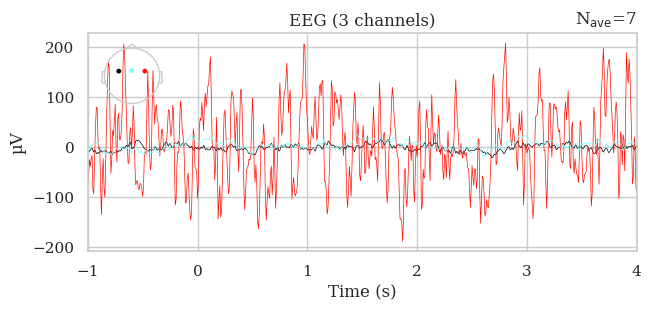

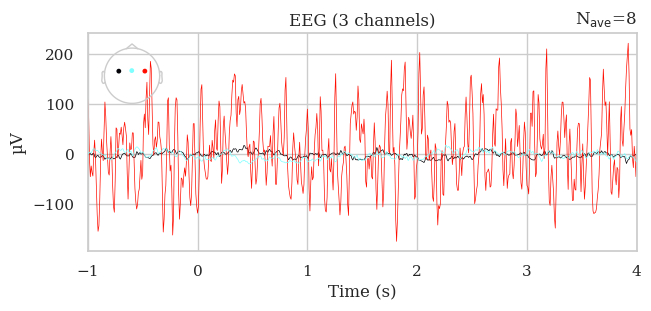

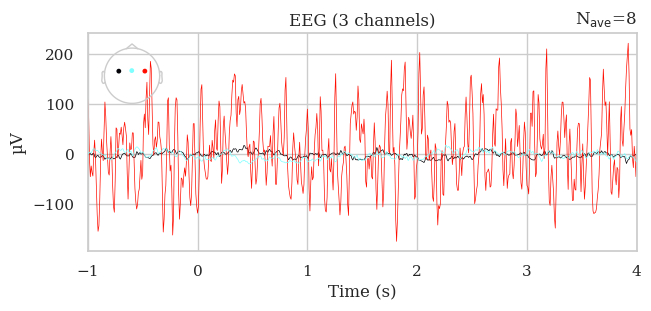

In [25]:
import mne
import numpy as np
import matplotlib.pyplot as plt

raw = DATASET.datasets[0].raw.copy()

event_id = {"left_hand": 1, "right_hand": 2}

events, event_id = mne.events_from_annotations(raw, event_id=event_id)

epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=-1.0,
    tmax=4.0,
    baseline=(-0.5, 0.0),
    preload=True,
    picks=["C3", "C4", "Cz"],
)

left = epochs["left_hand"].average()
right = epochs["right_hand"].average()

left.plot(spatial_colors=True)
right.plot(spatial_colors=True)

## 3.5. Get Subject Windows

In [26]:
def get_subject_windows(windows_dataset, subjects):
    """Split a windows dataset into one subset per subject id."""
    target_subjects = {str(s) for s in subjects}
    subject_to_indices = {str(s): [] for s in subjects}

    for idx, ds in enumerate(windows_dataset.datasets):
        subject_id = str(ds.description.get("subject"))
        if subject_id in target_subjects:
            subject_to_indices[subject_id].append(idx)

    missing_subjects = [sid for sid, idxs in subject_to_indices.items() if len(idxs) == 0]
    if missing_subjects:
        print(
            f"Subjects with no windows after filtering: {missing_subjects}"
        )

    subject_windows = {}
    for sid in sorted(subject_to_indices.keys(), key=int):
        idxs = subject_to_indices[sid]
        if len(idxs) == 0:
            continue
        subject_windows[sid] = BaseConcatDataset([windows_dataset.datasets[i] for i in idxs])

    if len(subject_windows) == 0:
        raise RuntimeError(
            "No subject windows were created. Ensure windows carry subject metadata and labels exist."
        )

    return subject_windows

In [27]:
SUBJECT_WINDOWS = get_subject_windows(WINDOWS_DATASET, SUBJECTS)

In [28]:
def summarize_subject_windows(subject_windows, n_classes):
    """Summarize per-subject window counts and class balance."""
    print("Summarizing per-subject windows...")
    for subject_id in sorted(subject_windows):
        ds = subject_windows[subject_id]
        y = np.asarray([int(ds[i][1]) for i in range(len(ds))], dtype=np.int64)
        counts = np.bincount(y, minlength=n_classes)
        sample = ds[0]
        x = sample[0]

        print(
            f"  Subject {subject_id}: n_windows={len(ds)}, "
            f"window_shape={tuple(x.shape)}, class_counts={counts.tolist()}"
        )

summarize_subject_windows(SUBJECT_WINDOWS, TARGET_N_CLASSES)

[2026-04-23 12:30:35] Summarizing per-subject windows...
[2026-04-23 12:30:35]   Subject 109: n_windows=45, window_shape=(64, 409), class_counts=[23, 22]


# 4. Model

## 4.1. Build Model

In [29]:
MODEL_REGISTRY = {
    "SignalJEPA_PreLocal": SignalJEPA_PreLocal,
    "SignalJEPA_PostLocal": SignalJEPA_PostLocal,
    "SignalJEPA_Contextual": SignalJEPA_Contextual,
}

DEFAULT_PRETRAINED_REPOS = {
    "SignalJEPA_Contextual": "braindecode/signal-jepa",
    "SignalJEPA_PostLocal": "braindecode/signal-jepa_without-chans",
    "SignalJEPA_PreLocal": "braindecode/signal-jepa_without-chans",
}

def get_model_class(model_name) -> SignalJEPA_PreLocal | SignalJEPA_PostLocal | SignalJEPA_Contextual:
    """Resolve downstream model class from config name with validation."""
    if model_name not in MODEL_REGISTRY:
        supported = ", ".join(MODEL_REGISTRY.keys())
        raise ValueError(f"Unsupported model_name '{model_name}'. Supported: {supported}")
    return MODEL_REGISTRY[model_name]

def get_default_pretrained_repo(model_name) -> str:
    """Resolve the default pretrained repo for a downstream model."""
    if model_name not in DEFAULT_PRETRAINED_REPOS:
        supported = ", ".join(DEFAULT_PRETRAINED_REPOS.keys())
        raise ValueError(f"Unsupported model_name for repo resolution '{model_name}'. Supported: {supported}")
    return DEFAULT_PRETRAINED_REPOS[model_name]

def build_model(model_name) -> tuple[SignalJEPA_PreLocal | SignalJEPA_PostLocal | SignalJEPA_Contextual, str]:
    """Instantiate the configured downstream model from pretrained weights."""
    model_cls = get_model_class(model_name)
    repo_id = get_default_pretrained_repo(model_name)
    n_chans = len(CHS_INFO)
    n_times = WINDOW_SAMPLES

    if not LOG_COMPACT:
        print(f"Building model class: {model_name}")
        print(f"Using pretrained repo: {repo_id}")
        print(f"Input shape: n_chans={n_chans}, n_times={n_times}")

    model = model_cls.from_pretrained(
        repo_id,
        n_chans=n_chans,
        n_times=n_times,
        n_outputs=TARGET_N_CLASSES,
        strict=False,
    )
    return model, repo_id

In [30]:
# Verify once that the selected model builds without error
test_model, test_repo = build_model(CONFIG["model_name"])
total_p = sum(p.numel() for p in test_model.parameters())
trainable_p = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"{CONFIG['model_name']} instantiated successfully from {test_repo}.")
print(f"  Total parameters:     {total_p:,}")
print(f"  Trainable parameters: {trainable_p:,}")
if PRINT_MODEL_SUMMARY:
    print(test_model)
del test_model

[2026-04-23 12:30:36] SignalJEPA_PreLocal instantiated successfully from braindecode/signal-jepa_without-chans.
[2026-04-23 12:30:36]   Total parameters:     15,638
[2026-04-23 12:30:36]   Trainable parameters: 15,638


## 4.2. Load Pretrained Weights

In [31]:
PRETRAINED_CHECKPOINT_INFO = {}

def initialize_model_with_pretrained_weights(model_name):
    """Initialize the downstream model from the default pretrained repository."""
    model, repo_id = build_model(model_name)
    pretrained_info = {
        "loading_path": "from_pretrained",
        "model_name": model_name,
        "repo_id": repo_id,
    }
    return model, pretrained_info

## 4.3. Trainable Parameter Phases

In [32]:
NEW_LAYER_PREFIXES = {
    "SignalJEPA_PreLocal": ("spatial_conv.", "final_layer."),
    "SignalJEPA_PostLocal": ("final_layer.",),
    "SignalJEPA_Contextual": ("pos_encoder.", "final_layer."),
}

def count_total_and_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [33]:
def get_new_layer_prefixes(model_name):
    if model_name not in NEW_LAYER_PREFIXES:
        raise ValueError(f"Unsupported model_name for trainable phase logic: {model_name}")
    return NEW_LAYER_PREFIXES[model_name]

def set_trainable_params_for_phase(model, model_name, phase):
    """
    Configure trainable parameters by phase.

    phase='new' or 'warmup': only newly introduced downstream layers are trainable.
    phase='full': full model is trainable.
    """
    if phase not in ("new", "warmup", "full"):
        raise ValueError(f"Unsupported phase: {phase}")

    trainable_names = []

    if phase == "full":
        for _, param in model.named_parameters():
            param.requires_grad = True
        trainable_names = [name for name, p in model.named_parameters() if p.requires_grad]
        phase_groups = ["all_parameters"]
    else:
        downstream_prefixes = get_new_layer_prefixes(model_name)
        for _, param in model.named_parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if any(name.startswith(prefix) for prefix in downstream_prefixes):
                param.requires_grad = True
                trainable_names.append(name)
        phase_groups = list(downstream_prefixes)

    total, trainable = count_total_and_trainable_params(model)

    if trainable == 0:
        raise RuntimeError(
            f"No trainable parameters found for model={model_name}, phase={phase}."
        )

    return {
        "model_name": model_name,
        "phase": phase,
        "trainable_groups": phase_groups,
        "total_params": int(total),
        "trainable_params": int(trainable),
        "trainable_ratio": float(trainable / total),
        "trainable_names": trainable_names,
    }

def assert_expected_trainable_scope(summary, model_name, phase):
    if phase == "full":
        return

    allowed_prefixes = get_new_layer_prefixes(model_name)
    unexpected_names = [
        name for name in summary["trainable_names"]
        if not any(name.startswith(prefix) for prefix in allowed_prefixes)
    ]

    if unexpected_names:
        raise RuntimeError(
            f"Unexpected trainable parameters for {model_name} phase={phase}: {unexpected_names[:10]}"
        )

def describe_trainable_params(summary, max_names=12):
    print(f"      Trainable groups: {summary['trainable_groups']}")
    print(f"      Total params:     {summary['total_params']:,}")
    print(f"      Trainable params: {summary['trainable_params']:,}")
    print(f"      Trainable pct:    {100.0 * summary['trainable_ratio']:.2f}%")

    if PRINT_FREEZE_DETAILS or not LOG_COMPACT or len(summary["trainable_names"]) <= max_names:
        preview_names = summary["trainable_names"]
    else:
        preview_names = summary["trainable_names"][:max_names]

    print(f"      Trainable parameter names: {preview_names}")
    if len(preview_names) < len(summary["trainable_names"]):
        print(f"      ... {len(summary['trainable_names']) - len(preview_names)} additional trainable parameters hidden")

# 5. Training

## 5.1. EEGClassifier Fold Runner

In [34]:
def get_targets(dataset):
    """Extract integer labels from a Braindecode dataset/subset."""
    return np.asarray([int(dataset[i][1]) for i in range(len(dataset))], dtype=np.int64)

In [35]:
def build_classifier(model, callbacks, max_epochs, fold_seed=None, warm_start=False):
    train_generator = None
    if fold_seed is not None:
        train_generator = torch.Generator()
        train_generator.manual_seed(fold_seed)

    clf_kwargs = {
        "batch_size": CONFIG["batch_size"],
        "max_epochs": int(max_epochs),
        "device": DEVICE,
        "callbacks": callbacks,
        "train_split": ValidSplit(cv=CONFIG['val_split'], stratified=True, random_state=12),
        "classes": range(TARGET_N_CLASSES),
        "iterator_train__shuffle": True,
        "iterator_train__num_workers": 0,
        "iterator_valid__num_workers": 0,
        "optimizer": torch.optim.Adam,
        "warm_start": warm_start,
    }

    if CONFIG["learning_rate"] is not None:
        clf_kwargs["lr"] = CONFIG["learning_rate"]

    if train_generator is not None:
        clf_kwargs["iterator_train__generator"] = train_generator

    return EEGClassifier(model, **clf_kwargs)

def run_one_batch_finite_sanity_check(model, train_set, model_name):
    """Fail fast if one-batch forward/loss contains NaN/Inf."""
    if len(train_set) == 0:
        raise RuntimeError(f"{model_name}: train_set is empty during sanity check.")

    batch_size = int(min(CONFIG["batch_size"], len(train_set)))
    sanity_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    batch = next(iter(sanity_loader))

    if not isinstance(batch, (tuple, list)) or len(batch) < 2:
        raise RuntimeError(f"{model_name}: expected batch with at least (X, y), got type={type(batch)}")

    x_batch = batch[0]
    y_batch = batch[1]
    x_batch = torch.as_tensor(x_batch).float().to(DEVICE)
    y_batch = torch.as_tensor(y_batch).long().to(DEVICE)

    was_training = model.training
    model = model.to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(x_batch)
        if not torch.isfinite(logits).all():
            raise RuntimeError(
                f"{model_name}: non-finite logits detected in one-batch sanity check."
            )

        loss = torch.nn.functional.cross_entropy(logits, y_batch)
        if not torch.isfinite(loss):
            raise RuntimeError(
                f"{model_name}: non-finite loss detected in one-batch sanity check."
            )

    if was_training:
        model.train()

    print(
        f"    Sanity check passed: finite logits/loss on one training batch for {model_name}."
    )

def extract_binary_score_vector(score_output, expected_n_samples):
    """Normalize model score output into a 1D score vector for binary ROC-AUC."""
    if score_output is None:
        return None

    scores = np.asarray(score_output)

    if scores.ndim == 1:
        score_vec = scores.astype(float)
    elif scores.ndim == 2 and scores.shape[1] == 2:
        score_vec = scores[:, 1].astype(float)
    elif scores.ndim == 2 and scores.shape[1] == 1:
        score_vec = scores[:, 0].astype(float)
    else:
        print(
            f"    ROC-AUC score extraction skipped: unsupported score shape {tuple(scores.shape)} for binary task."
        )
        return None

    if score_vec.shape[0] != int(expected_n_samples):
        print(
            "    ROC-AUC score extraction skipped: sample count mismatch "
            f"(scores={score_vec.shape[0]} vs labels={expected_n_samples})."
        )
        return None

    if not np.isfinite(score_vec).all():
        print("    ROC-AUC score extraction skipped: non-finite values detected in score vector.")
        return None

    return score_vec

def compute_classification_metrics(y_true, y_pred, y_score=None, paradigm=None):
    """Compute accuracy/balanced accuracy always and ROC-AUC when applicable."""
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_pred = np.asarray(y_pred).astype(int).reshape(-1)

    metrics = {
        "accuracy": None,
        "balanced_accuracy": None,
        "roc_auc": None,
    }

    try:
        metrics["accuracy"] = float(accuracy_score(y_true, y_pred)) # type: ignore
    except Exception as exc:
        print(f"    Accuracy computation failed: {exc}")

    try:
        metrics["balanced_accuracy"] = float(balanced_accuracy_score(y_true, y_pred)) # type: ignore
    except Exception as exc:
        print(f"    Balanced accuracy computation failed: {exc}")

    if paradigm == "ERP":
        if y_score is None:
            print("    ERP ROC-AUC skipped: score/probability output is unavailable.")
        elif len(np.unique(y_true)) < 2:
            print("    ERP ROC-AUC skipped: only one class present in y_true for this fold.")
        else:
            try:
                metrics["roc_auc"] = float(roc_auc_score(y_true, y_score)) # type: ignore
            except Exception as exc:
                print(f"    ERP ROC-AUC skipped: {exc}")

    return metrics

def run_single_fold(fold_id, subject_id, subject_dataset, idx_train, idx_test):
    """Train and evaluate one fold using EEGClassifier on dataset subsets."""
    global PRETRAINED_CHECKPOINT_INFO

    if CONFIG["set_seed"]:
        fold_seed = BASE_SEED
        seed_everything(fold_seed) # type: ignore
    else:
        fold_seed = None

    train_set = Subset(subject_dataset, idx_train.tolist())
    test_set = Subset(subject_dataset, idx_test.tolist())

    y_all = get_targets(subject_dataset)
    y_train = y_all[idx_train]
    y_test = y_all[idx_test]

    train_counts = np.bincount(y_train, minlength=TARGET_N_CLASSES)
    test_counts = np.bincount(y_test, minlength=TARGET_N_CLASSES)

    if PRINT_FOLD_CLASS_COUNTS:
        print(f"    Train class counts: {train_counts.tolist()}")
        print(f"    Test class counts:  {test_counts.tolist()}")

    model_name = CONFIG["model_name"]
    strategy = CONFIG["strategy"]
    warmup_epochs = int(CONFIG["warmup_epochs"])

    model, pretrained_load_summary = initialize_model_with_pretrained_weights(model_name)
    PRETRAINED_CHECKPOINT_INFO = dict(pretrained_load_summary)

    print(f"    Downstream model:        {model_name}")
    print(f"    Fine-tune strategy:      {strategy}")
    print(f"    Warm-up active:          {strategy == 'full'}")
    print(f"    Warm-up epochs:          {warmup_epochs}")
    print(f"    Pretrained loading path: {pretrained_load_summary['loading_path']}")
    print(f"    Pretrained repo:         {pretrained_load_summary['repo_id']}")

    if strategy == "new":
        phase_1_summary = set_trainable_params_for_phase(model, model_name, "new")
        assert_expected_trainable_scope(phase_1_summary, model_name, "new")
        print("    Phase 1 (new):")
        describe_trainable_params(phase_1_summary)

        run_one_batch_finite_sanity_check(model, train_set, model_name)

        callbacks = [
            (
                "early_stopping",
                EarlyStopping(
                    monitor="valid_loss",
                    patience=CONFIG["early_stopping_patience"],
                    lower_is_better=True,
                    load_best=True,
                ),
            ),
        ]

        clf = build_classifier(
            model=model,
            callbacks=callbacks,
            max_epochs=int(CONFIG["n_epochs"]),
            fold_seed=fold_seed,
            warm_start=False,
        )

        phase_summaries = {
            "phase_1": phase_1_summary,
            "phase_2": None,
        }
        clf.fit(train_set, y=y_train)

    elif strategy == "full":
        if warmup_epochs < 1:
            raise ValueError("For strategy='full', warmup_epochs must be >= 1.")

        phase_1_summary = set_trainable_params_for_phase(model, model_name, "warmup")
        assert_expected_trainable_scope(phase_1_summary, model_name, "warmup")
        print("    Phase 1 (warmup):")
        describe_trainable_params(phase_1_summary)

        run_one_batch_finite_sanity_check(model, train_set, model_name)

        clf = build_classifier(
            model=model,
            callbacks=[],
            max_epochs=warmup_epochs,
            fold_seed=fold_seed,
            warm_start=True,
        )

        clf.fit(train_set, y=y_train)

        phase_2_summary = set_trainable_params_for_phase(clf.module_, model_name, "full")
        print("    Phase 2 (full):")
        describe_trainable_params(phase_2_summary)

        # Important: refresh optimizer so newly unfrozen parameters are trainable.
        clf.initialize_optimizer()

        remaining_epochs = int(CONFIG["n_epochs"]) - warmup_epochs
        if remaining_epochs < 1:
            raise ValueError(
                "CONFIG['n_epochs'] must be greater than CONFIG['warmup_epochs'] when strategy='full'."
            )

        callbacks = [
            (
                "early_stopping",
                EarlyStopping(
                    monitor="valid_loss",
                    patience=CONFIG["early_stopping_patience"],
                    lower_is_better=True,
                    load_best=True,
                ),
            ),
        ]

        clf.set_params(callbacks=callbacks, max_epochs=remaining_epochs)
        clf.fit(train_set, y=y_train)

        phase_summaries = {
            "phase_1": phase_1_summary,
            "phase_2": phase_2_summary,
        }
    else:
        raise ValueError(f"Unsupported strategy: {strategy}. Use 'new' or 'full'.")

    y_pred = clf.predict(test_set)

    y_score_raw = None
    if hasattr(clf, "predict_proba"):
        try:
            y_score_raw = clf.predict_proba(test_set)
        except Exception as exc:
            print(f"    predict_proba unavailable on this fold: {exc}")

    decision_fn = getattr(clf, "decision_function", None)
    if y_score_raw is None and callable(decision_fn):
        try:
            y_score_raw = decision_fn(test_set)
        except Exception as exc:
            print(f"    decision_function unavailable on this fold: {exc}")

    y_score = None
    if CONFIG["paradigm"] == "ERP":
        y_score = extract_binary_score_vector(y_score_raw, expected_n_samples=len(y_test))

    metrics = compute_classification_metrics(
        y_true=y_test,
        y_pred=y_pred,
        y_score=y_score,
        paradigm=CONFIG["paradigm"],
    )

    stopped_epoch = int(clf.history[-1]["epoch"]) if len(clf.history) > 0 else 0 # type: ignore
    valid_loss_curve = [
        (int(row["epoch"]), float(row["valid_loss"]))
        for row in clf.history
        if "valid_loss" in row
    ]

    if valid_loss_curve:
        best_epoch, best_valid_loss = min(valid_loss_curve, key=lambda x: x[1])
    else:
        best_epoch, best_valid_loss = None, None

    acc = metrics["accuracy"]
    bal_acc = metrics["balanced_accuracy"]
    roc_auc = metrics["roc_auc"]

    cm = confusion_matrix(y_test, y_pred, labels=np.arange(TARGET_N_CLASSES)).tolist()
    pred_hist = np.bincount(y_pred, minlength=TARGET_N_CLASSES).tolist()

    n_folds = CONFIG["cv_folds"]
    val_loss_str = f"{best_valid_loss:.4f}" if best_valid_loss is not None else "N/A"
    acc_str = f"{acc:.4f}" if acc is not None else "N/A"
    bal_acc_str = f"{bal_acc:.4f}" if bal_acc is not None else "N/A"
    roc_auc_str = f"{roc_auc:.4f}" if roc_auc is not None else "N/A"
    print(
        f"  Fold {fold_id}/{n_folds} | best_epoch={best_epoch} | stop={stopped_epoch} "
        f"| val_loss={val_loss_str} | acc={acc_str} | bal_acc={bal_acc_str} | roc_auc={roc_auc_str}"
    )

    return {
        "subject_id": str(subject_id),
        "fold_id": fold_id,
        "paradigm": CONFIG["paradigm"],
        "model_name": model_name,
        "strategy": strategy,
        "warmup_epochs": warmup_epochs,
        "n_train": len(train_set),
        "n_test": len(test_set),
        "train_class_counts": train_counts.tolist(),
        "test_class_counts": test_counts.tolist(),
        "pretrained_load": pretrained_load_summary,
        "phase_1_trainable_groups": phase_summaries["phase_1"]["trainable_groups"],
        "phase_1_trainable_params": phase_summaries["phase_1"]["trainable_params"],
        "phase_1_trainable_names": phase_summaries["phase_1"]["trainable_names"],
        "phase_2_trainable_groups": None if phase_summaries["phase_2"] is None else phase_summaries["phase_2"]["trainable_groups"],
        "phase_2_trainable_params": None if phase_summaries["phase_2"] is None else phase_summaries["phase_2"]["trainable_params"],
        "phase_2_trainable_names": None if phase_summaries["phase_2"] is None else phase_summaries["phase_2"]["trainable_names"],
        "best_epoch": best_epoch,
        "stopped_epoch": stopped_epoch,
        "best_valid_loss": best_valid_loss,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "prediction_histogram": pred_hist,
    }


## 5.2. Subject Cross-Validation Runner

In [36]:
def make_fold_splits(y, n_folds, n_classes):
    """Create stratified k-fold index splits for one subject."""
    indices = np.arange(len(y))
    skf = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=12,
    )
    folds = []

    for fold_id, (train_idx, test_idx) in enumerate(skf.split(indices, y), start=1):
        y_test_f = y[test_idx]

        if PRINT_FOLD_CLASS_COUNTS:
            train_counts = np.bincount(y[train_idx], minlength=n_classes)
            test_counts = np.bincount(y_test_f, minlength=n_classes)
            print(f"  Fold {fold_id} class counts: train={train_counts.tolist()} test={test_counts.tolist()}")

        folds.append(
            {
                "fold_id": fold_id,
                "idx_train": train_idx,
                "idx_test": test_idx,
            }
        )

    return folds

In [37]:
def run_subject_cv(subject_id, subject_dataset, n_classes, cv_folds):
    """Run within-subject stratified CV for one subject."""
    y = get_targets(subject_dataset)
    counts = np.bincount(y, minlength=n_classes)
    print(f"\nSubject {subject_id}: {len(subject_dataset)} windows | class_counts={counts.tolist()}")

    folds = make_fold_splits(
        y,
        n_folds=cv_folds,
        n_classes=n_classes,
    )
    results = []

    for fold in folds:
        result = run_single_fold(
            fold["fold_id"],
            subject_id,
            subject_dataset,
            fold["idx_train"],
            fold["idx_test"],
        )
        results.append(result)

    acc_values = [r["accuracy"] for r in results if r["accuracy"] is not None]
    bal_acc_values = [r["balanced_accuracy"] for r in results if r["balanced_accuracy"] is not None]
    roc_auc_values = [r["roc_auc"] for r in results if r["roc_auc"] is not None]

    mean_acc = float(np.mean(acc_values)) if len(acc_values) > 0 else None
    mean_bal_acc = float(np.mean(bal_acc_values)) if len(bal_acc_values) > 0 else None
    std_acc = float(np.std(acc_values)) if len(acc_values) > 0 else None
    std_bal_acc = float(np.std(bal_acc_values)) if len(bal_acc_values) > 0 else None
    mean_roc_auc = float(np.mean(roc_auc_values)) if len(roc_auc_values) > 0 else None
    std_roc_auc = float(np.std(roc_auc_values)) if len(roc_auc_values) > 0 else None


    acc_str = f"{mean_acc:.4f}±{std_acc:.4f}" if mean_acc is not None and std_acc is not None else "N/A"
    bal_acc_str = f"{mean_bal_acc:.4f}±{std_bal_acc:.4f}" if mean_bal_acc is not None and std_bal_acc is not None else "N/A"
    roc_auc_str = f"{mean_roc_auc:.4f}±{std_roc_auc:.4f}" if mean_roc_auc is not None and std_roc_auc is not None else "N/A"

    print(
        f"  Subject {subject_id} summary: acc={acc_str}  bal_acc={bal_acc_str}  "
        f"roc_auc={roc_auc_str}"
    )

    return results


## 5.3. Run All Subjects

In [38]:
print("=" * 70)
print("STARTING CROSS-VALIDATION")
print("=" * 70)
print(f"Subjects:      {list(SUBJECT_WINDOWS.keys())}")
print(f"Paradigm:      {CONFIG['paradigm']}")
print(f"Model:         {CONFIG['model_name']}")
print(f"Strategy:      {CONFIG['strategy']}")
print(f"Warm-up epochs:{CONFIG['warmup_epochs']}")
print(f"CV folds:      {CONFIG['cv_folds']}")
print(f"Batch size:    {CONFIG['batch_size']}")
print(f"Learning rate: {CONFIG['learning_rate']}")
print(f"Max epochs:    {CONFIG['n_epochs']}")
print(f"Device:        {DEVICE}")
print(f"Seed control:  {CONFIG['set_seed']}")
print(f"CV seed:       {BASE_SEED}")
print("=" * 70)

FOLD_RESULTS = []

for sid, subject_ds in SUBJECT_WINDOWS.items():
    fold_results = run_subject_cv(
        sid,
        subject_ds,
        TARGET_N_CLASSES,
        CONFIG["cv_folds"],
    )
    FOLD_RESULTS.extend(fold_results)

print(f"\nTotal folds completed: {len(FOLD_RESULTS)}")

[2026-04-23 12:30:36] ======================================================================
[2026-04-23 12:30:36] STARTING CROSS-VALIDATION
[2026-04-23 12:30:36] ======================================================================
[2026-04-23 12:30:36] Subjects:      ['109']
[2026-04-23 12:30:36] Paradigm:      MI
[2026-04-23 12:30:36] Model:         SignalJEPA_PreLocal
[2026-04-23 12:30:36] Strategy:      full
[2026-04-23 12:30:36] Warm-up epochs:10
[2026-04-23 12:30:36] CV folds:      5
[2026-04-23 12:30:36] Batch size:    32
[2026-04-23 12:30:36] Learning rate: 0.001
[2026-04-23 12:30:36] Max epochs:    5000
[2026-04-23 12:30:36] Device:        mps
[2026-04-23 12:30:36] Seed control:  True
[2026-04-23 12:30:36] CV seed:       12
[2026-04-23 12:30:36] ======================================================================

[2026-04-23 12:30:36] Subject 109: 45 windows | class_counts=[23, 22]
[2026-04-23 12:30:37]     Downstream model:        SignalJEPA_PreLocal
[2026-04-23 12:30:37

# 6. Results

## 6.1. Aggregate Metrics

In [39]:
# Per-subject aggregation
SUBJECT_METRICS = {}

for result in FOLD_RESULTS:
    sid = result["subject_id"]
    if sid not in SUBJECT_METRICS:
        SUBJECT_METRICS[sid] = {
            "accuracies": [],
            "balanced_accuracies": [],
            "roc_aucs": [],
        }
    SUBJECT_METRICS[sid]["accuracies"].append(result["accuracy"])
    SUBJECT_METRICS[sid]["balanced_accuracies"].append(result["balanced_accuracy"])
    SUBJECT_METRICS[sid]["roc_aucs"].append(result.get("roc_auc"))

for sid, m in SUBJECT_METRICS.items():
    acc_values = [v for v in m["accuracies"] if v is not None]
    bal_acc_values = [v for v in m["balanced_accuracies"] if v is not None]
    roc_auc_values = [v for v in m["roc_aucs"] if v is not None]

    m["mean_accuracy"] = float(np.mean(acc_values)) if len(acc_values) > 0 else None
    m["std_accuracy"] = float(np.std(acc_values)) if len(acc_values) > 0 else None
    m["mean_balanced_accuracy"] = float(np.mean(bal_acc_values)) if len(bal_acc_values) > 0 else None
    m["std_balanced_accuracy"] = float(np.std(bal_acc_values)) if len(bal_acc_values) > 0 else None
    m["mean_roc_auc"] = float(np.mean(roc_auc_values)) if len(roc_auc_values) > 0 else None
    m["std_roc_auc"] = float(np.std(roc_auc_values)) if len(roc_auc_values) > 0 else None

# Global aggregation
all_accs = [r["accuracy"] for r in FOLD_RESULTS if r["accuracy"] is not None]
all_bal_accs = [r["balanced_accuracy"] for r in FOLD_RESULTS if r["balanced_accuracy"] is not None]
all_roc_aucs = [r["roc_auc"] for r in FOLD_RESULTS if r.get("roc_auc") is not None]

mean_accuracy = float(np.mean(all_accs)) if len(all_accs) > 0 else None
std_accuracy = float(np.std(all_accs)) if len(all_accs) > 0 else None
mean_balanced_accuracy = float(np.mean(all_bal_accs)) if len(all_bal_accs) > 0 else None
std_balanced_accuracy = float(np.std(all_bal_accs)) if len(all_bal_accs) > 0 else None
mean_roc_auc = float(np.mean(all_roc_aucs)) if len(all_roc_aucs) > 0 else None
std_roc_auc = float(np.std(all_roc_aucs)) if len(all_roc_aucs) > 0 else None


GLOBAL_METRICS = {
    "mean_accuracy": mean_accuracy,
    "std_accuracy": std_accuracy,
    "mean_balanced_accuracy": mean_balanced_accuracy,
    "std_balanced_accuracy": std_balanced_accuracy,
    "mean_roc_auc": mean_roc_auc,
    "std_roc_auc": std_roc_auc,
    "n_subjects": len(SUBJECT_METRICS),
    "n_folds_total": len(FOLD_RESULTS),
}

print("=" * 70)
print("AGGREGATED RESULTS")
print("=" * 70)
for sid, m in sorted(SUBJECT_METRICS.items()):
    acc_str = f"{m['mean_accuracy']:.4f}±{m['std_accuracy']:.4f}" if m["mean_accuracy"] is not None and m["std_accuracy"] is not None else "N/A"
    bal_acc_str = f"{m['mean_balanced_accuracy']:.4f}±{m['std_balanced_accuracy']:.4f}" if m["mean_balanced_accuracy"] is not None and m["std_balanced_accuracy"] is not None else "N/A"
    roc_auc_str = f"{m['mean_roc_auc']:.4f}±{m['std_roc_auc']:.4f}" if m["mean_roc_auc"] is not None and m["std_roc_auc"] is not None else "N/A"
    print(
        f"  Subject {sid}:  acc={acc_str}  bal_acc={bal_acc_str}  "
        f"roc_auc={roc_auc_str} "
    )
print("-" * 70)
overall_acc_str = f"{GLOBAL_METRICS['mean_accuracy']:.4f}±{GLOBAL_METRICS['std_accuracy']:.4f}" if GLOBAL_METRICS["mean_accuracy"] is not None and GLOBAL_METRICS["std_accuracy"] is not None else "N/A"
overall_bal_acc_str = f"{GLOBAL_METRICS['mean_balanced_accuracy']:.4f}±{GLOBAL_METRICS['std_balanced_accuracy']:.4f}" if GLOBAL_METRICS["mean_balanced_accuracy"] is not None and GLOBAL_METRICS["std_balanced_accuracy"] is not None else "N/A"
overall_roc_auc_str = f"{GLOBAL_METRICS['mean_roc_auc']:.4f}±{GLOBAL_METRICS['std_roc_auc']:.4f}" if GLOBAL_METRICS["mean_roc_auc"] is not None and GLOBAL_METRICS["std_roc_auc"] is not None else "N/A"
print(
    f"  OVERALL:      acc={overall_acc_str}  bal_acc={overall_bal_acc_str}  "
    f"roc_auc={overall_roc_auc_str}"
)
print("=" * 70)

[2026-04-23 12:33:33] ======================================================================
[2026-04-23 12:33:33] AGGREGATED RESULTS
[2026-04-23 12:33:33] ======================================================================
[2026-04-23 12:33:33]   Subject 109:  acc=0.5111±0.0544  bal_acc=0.5000±0.0000  roc_auc=N/A 
[2026-04-23 12:33:33] ----------------------------------------------------------------------
[2026-04-23 12:33:33]   OVERALL:      acc=0.5111±0.0544  bal_acc=0.5000±0.0000  roc_auc=N/A
[2026-04-23 12:33:33] ======================================================================


## 6.2. Save Outputs

In [40]:
cv_results_path = ARTIFACT_DIR / "cv_results.json"
with open(cv_results_path, 'w') as f:
    json.dump(FOLD_RESULTS, f, indent=2)
print(f"CV results saved to:      {cv_results_path}")

subject_metrics_path = ARTIFACT_DIR / "subject_metrics.json"
with open(subject_metrics_path, 'w') as f:
    json.dump(SUBJECT_METRICS, f, indent=2)
print(f"Subject metrics saved to: {subject_metrics_path}")

global_metrics_path = ARTIFACT_DIR / "global_metrics.json"
with open(global_metrics_path, 'w') as f:
    json.dump(GLOBAL_METRICS, f, indent=2)
print(f"Global metrics saved to:  {global_metrics_path}")

run_metadata = {
    "run_id": RUN_ID,
    "artifact_dir": str(ARTIFACT_DIR),
    "dataset_name": CONFIG["dataset_name"],
    "dataset_source": CONFIG["dataset_source"],
    "preprocessed_concat_dir": str(PREPROCESSED_CONCAT_DIR),
    "labels_to_keep": list(CONFIG["labels_to_keep"]),
    "excluded_subjects": list(CONFIG["exclude_subjects"]),
    "paradigm": CONFIG["paradigm"],
    "subjects": [str(s) for s in SUBJECTS],
    "model_name": CONFIG["model_name"],
    "strategy": CONFIG["strategy"],
    "warmup_epochs": int(CONFIG["warmup_epochs"]),
    "pretrained_checkpoint_info": PRETRAINED_CHECKPOINT_INFO,
    "cv_seed": BASE_SEED,
    "global_metrics": GLOBAL_METRICS,
}

run_metadata_path = ARTIFACT_DIR / "run_metadata.json"
with open(run_metadata_path, 'w') as f:
    json.dump(run_metadata, f, indent=2)
print(f"Run metadata saved to:    {run_metadata_path}")

print(f"\nAll artifacts in: {ARTIFACT_DIR}")


[2026-04-23 12:33:33] CV results saved to:      /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/physionet-2009-fine-tuning/MI/20260423_1230_2b697689/cv_results.json
[2026-04-23 12:33:33] Subject metrics saved to: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/physionet-2009-fine-tuning/MI/20260423_1230_2b697689/subject_metrics.json
[2026-04-23 12:33:33] Global metrics saved to:  /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/physionet-2009-fine-tuning/MI/20260423_1230_2b697689/global_metrics.json
[2026-04-23 12:33:33] Run metadata saved to:    /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/physionet-2009-fine-tuning/MI/20260423_1230_2b697689/run_metadata.json

[2026-04-23 12:33:33] All artifacts in: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/physionet-2009-fine-tunin

## 6.3. Final Summary

In [41]:
print("\n" + "=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)
print(f"Run ID:    {RUN_ID}")
print(f"Artifacts: {ARTIFACT_DIR}")
print()
print("Configuration:")
print(f"  Dataset name:           {CONFIG['dataset_name']}")
print(f"  Dataset source:         {CONFIG['dataset_source']}")
print(f"  Subjects:               {list(SUBJECTS)}")
print(f"  Excluded subjects:      {list(CONFIG['exclude_subjects'])}")
print(f"  Labels kept:            {list(CONFIG['labels_to_keep'])}")
print(f"  Paradigm:               {CONFIG['paradigm']}")
print(f"  Model:                  {CONFIG['model_name']}")
print(f"  Strategy:               {CONFIG['strategy']}")
print(f"  Warm-up epochs:         {CONFIG['warmup_epochs']}")
print(f"  Bandpass:               {CONFIG['bandpass_low']}-{CONFIG['bandpass_high']} Hz")
print(f"  Resample:               {CONFIG['sfreq']} Hz")
print(f"  CV folds:               {CONFIG['cv_folds']}")
print(f"  Validation split:       {CONFIG['val_split']}")
print(f"  Learning rate:          {CONFIG['learning_rate']}")
print(f"  Batch size:             {CONFIG['batch_size']}")
print(f"  Max epochs:             {CONFIG['n_epochs']}")
print(f"  CV seed:                {BASE_SEED}")
print(f"  Pretrained loading:     {PRETRAINED_CHECKPOINT_INFO.get('loading_path')}")
print()
print("Results:")
if GLOBAL_METRICS["mean_accuracy"] is not None and GLOBAL_METRICS["std_accuracy"] is not None:
    print(f"  Mean Accuracy:          {GLOBAL_METRICS['mean_accuracy']:.4f} ± {GLOBAL_METRICS['std_accuracy']:.4f}")
else:
    print("  Mean Accuracy:          N/A")

if GLOBAL_METRICS["mean_balanced_accuracy"] is not None and GLOBAL_METRICS["std_balanced_accuracy"] is not None:
    print(f"  Mean Balanced Accuracy: {GLOBAL_METRICS['mean_balanced_accuracy']:.4f} ± {GLOBAL_METRICS['std_balanced_accuracy']:.4f}")
else:
    print("  Mean Balanced Accuracy: N/A")

if GLOBAL_METRICS["mean_roc_auc"] is not None and GLOBAL_METRICS["std_roc_auc"] is not None:
    print(f"  Mean ROC-AUC:           {GLOBAL_METRICS['mean_roc_auc']:.4f} ± {GLOBAL_METRICS['std_roc_auc']:.4f}")
else:
    print("  Mean ROC-AUC:           N/A")



[2026-04-23 12:33:33] ======================================================================
[2026-04-23 12:33:33] EXPERIMENT SUMMARY
[2026-04-23 12:33:33] ======================================================================
[2026-04-23 12:33:33] Run ID:    20260423_1230_2b697689
[2026-04-23 12:33:33] Artifacts: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/physionet-2009-fine-tuning/MI/20260423_1230_2b697689

[2026-04-23 12:33:33] Configuration:
[2026-04-23 12:33:33]   Dataset name:           PhysionetMI
[2026-04-23 12:33:33]   Dataset source:         moabb
[2026-04-23 12:33:33]   Subjects:               [109]
[2026-04-23 12:33:33]   Excluded subjects:      []
[2026-04-23 12:33:33]   Labels kept:            ['left_hand', 'right_hand']
[2026-04-23 12:33:33]   Paradigm:               MI
[2026-04-23 12:33:33]   Model:                  SignalJEPA_PreLocal
[2026-04-23 12:33:33]   Strategy:               full
[2026-04-23 12:33:33]   Warm-up ep